In [25]:
#Импорт библиотек

In [26]:
from sklearn.cluster import KMeans
from sklearn.cluster import SpectralClustering
import xarray as xr
from scipy import stats
from sklearn_xarray import wrap
from sklearn_xarray.datasets import load_dummy_dataarray
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import numpy as np
import pandas as pd
import cartopy.feature as cfeature

In [27]:
#Загрузка данных и их нормализация

In [28]:
data = xr.open_dataset('dataset/2025_1000.nc',engine= 'netcdf4')
data=data.drop_vars("time_bnds")
#data=data.sel(bnds=1,drop=True)

In [29]:
data

<xarray.Dataset> Size: 32MB
Dimensions:  (time: 61, lev: 3, lat: 91, lon: 120)
Coordinates:
  * time     (time) datetime64[ns] 488B 2025-11-01T10:30:00 ... 2025-12-31T10...
  * lev      (lev) float64 24B 1e+03 500.0 300.0
  * lat      (lat) float64 728B -90.0 -88.0 -86.0 -84.0 ... 84.0 86.0 88.0 90.0
  * lon      (lon) float64 960B 0.0 3.0 6.0 9.0 12.0 ... 348.0 351.0 354.0 357.0
Data variables:
    H        (time, lev, lat, lon) float32 8MB ...
    T        (time, lev, lat, lon) float32 8MB ...
    U        (time, lev, lat, lon) float32 8MB ...
    V        (time, lev, lat, lon) float32 8MB ...
Attributes: (12/35)
    CDI:                               Climate Data Interface version 1.7.1 (...
    Conventions:                       CF-1
    history:                           Wed Jan 28 15:09:34 2026: cdo sellevel...
    _NCProperties:                     version=1|netcdflibversion=4.5.0|hdf5l...
    History:                           Original file generated: Tue Nov 11 21...
    Comment:                           GMAO filename: d5124_m2_jan10.inst3_3d...
    ...                                ...
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2025-11-01
    RangeEndingTime:                   21:00:00.000000
    frequency:                         day
    NCO:                               4.3.7
    CDO:                               Climate Data Operators version 1.7.1 (...

In [30]:
type(data)

xarray.core.dataset.Dataset

In [31]:

#Xt = wrap(StandardScaler()).fit_transform(data)

mean= data.mean(dim='time')
std = data.std(dim='time')
Xt = (data-mean)/std
Xt=Xt.isel(lev=0)
X_df= Xt.to_dataframe(dim_order =('time','lon','lat')) 
X=data.isel(lev=0).to_dataframe(dim_order =('time','lon','lat')) # не отнормализованный
X_df=X_df.reset_index()
X_df=X_df.iloc[:,4:-2] # нормализованный и усеченный

In [32]:
Xt

<xarray.Dataset> Size: 11MB
Dimensions:  (lon: 120, lat: 91, time: 61)
Coordinates:
  * lon      (lon) float64 960B 0.0 3.0 6.0 9.0 12.0 ... 348.0 351.0 354.0 357.0
  * lat      (lat) float64 728B -90.0 -88.0 -86.0 -84.0 ... 84.0 86.0 88.0 90.0
  * time     (time) datetime64[ns] 488B 2025-11-01T10:30:00 ... 2025-12-31T10...
    lev      float64 8B 1e+03
Data variables:
    H        (time, lat, lon) float32 3MB 0.3477 2.695 1.71 ... -1.995 -1.969
    T        (time, lat, lon) float32 3MB -0.2712 0.2124 ... -0.02012 -0.01275
    U        (time, lat, lon) float32 3MB 1.502 1.443 1.372 ... 2.721 2.678
    V        (time, lat, lon) float32 3MB 0.6235 0.4097 ... -0.01227 -0.09747
Attributes: (12/35)
    CDI:                               Climate Data Interface version 1.7.1 (...
    Conventions:                       CF-1
    history:                           Wed Jan 28 15:09:34 2026: cdo sellevel...
    _NCProperties:                     version=1|netcdflibversion=4.5.0|hdf5l...
    History:                           Original file generated: Tue Nov 11 21...
    Comment:                           GMAO filename: d5124_m2_jan10.inst3_3d...
    ...                                ...
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2025-11-01
    RangeEndingTime:                   21:00:00.000000
    frequency:                         day
    NCO:                               4.3.7
    CDO:                               Climate Data Operators version 1.7.1 (...

In [33]:
X_df.head(5)

,H,T
0,0.347682,-0.271171
1,0.347682,-0.271171
2,0.347682,-0.271171
3,0.345259,-0.263639
4,0.115625,-0.190686


In [34]:
X

H         T          U         V  \
time                lon   lat                                                
2025-11-01 10:30:00 0.0   -90.0   -5.423445 -4.133301   4.570474  2.031699   
                          -88.0   -5.423445 -4.133301   4.570474  2.031699   
                          -86.0   -5.423445 -4.133301   4.570474  2.031699   
                          -84.0   -5.847328 -3.828979   4.720197  1.897010   
                          -82.0   -6.308565 -3.814880   4.802876  1.922760   
...                                     ...       ...        ...       ...   
2025-12-31 10:30:00 357.0  82.0   65.736618 -3.523285   7.477954  0.790555   
                           84.0   24.189857  0.119553  12.793761 -0.472643   
                           86.0  -36.978096  3.391037  15.114601 -0.999090   
                           88.0  -98.637505  2.892120  15.177395 -0.118753   
                           90.0 -118.002846  3.068192  14.487812 -0.641080   

                                    lev  
time                lon   lat            
2025-11-01 10:30:00 0.0   -90.0  1000.0  
                          -88.0  1000.0  
                          -86.0  1000.0  
                          -84.0  1000.0  
                          -82.0  1000.0  
...                                 ...  
2025-12-31 10:30:00 357.0  82.0  1000.0  
                           84.0  1000.0  
                           86.0  1000.0  
                           88.0  1000.0  
                           90.0  1000.0  

[666120 rows x 5 columns]

In [35]:
#Определение достаточного количества кластеров

Text(0, 0.5, 'Инерция')

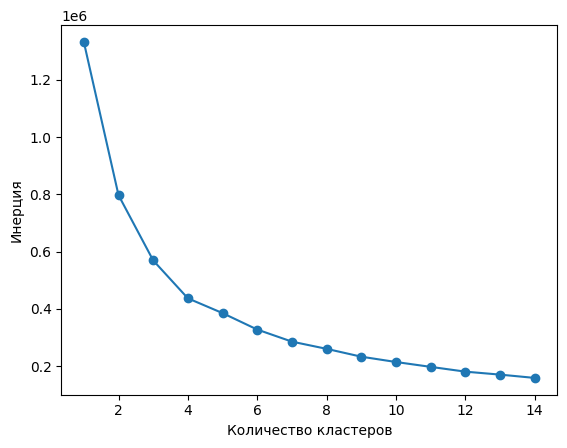

In [36]:
n_cluster=[]
inertia=[]

for i in range(1,15):
    kmeans = KMeans(n_clusters=i).fit(X_df)
    n_cluster.append(i)
    inertia.append(kmeans.inertia_)
plt.plot(n_cluster, inertia, marker="o")
plt.xlabel('Количество кластеров')
plt.ylabel('Инерция')

Кластеризация по K-средним

In [37]:
kmeans=KMeans(n_clusters=5).fit(X_df)
X["kmeans"]=kmeans.labels_
X_ar=X.to_xarray()
X_ar=X_ar.drop_vars('lev')
X_ar

<xarray.Dataset> Size: 13MB
Dimensions:  (time: 61, lon: 120, lat: 91)
Coordinates:
  * time     (time) datetime64[ns] 488B 2025-11-01T10:30:00 ... 2025-12-31T10...
  * lon      (lon) float64 960B 0.0 3.0 6.0 9.0 12.0 ... 348.0 351.0 354.0 357.0
  * lat      (lat) float64 728B -90.0 -88.0 -86.0 -84.0 ... 84.0 86.0 88.0 90.0
Data variables:
    H        (time, lon, lat) float32 3MB -5.423 -5.423 -5.423 ... -98.64 -118.0
    T        (time, lon, lat) float32 3MB -4.133 -4.133 -4.133 ... 2.892 3.068
    U        (time, lon, lat) float32 3MB 4.57 4.57 4.57 ... 15.11 15.18 14.49
    V        (time, lon, lat) float32 3MB 2.032 2.032 2.032 ... -0.1188 -0.6411
    kmeans   (time, lon, lat) int32 3MB 2 2 2 2 2 2 2 2 2 ... 2 0 0 0 0 2 2 1 3

In [38]:
X['H'].max()

np.float32(281.0838)

In [39]:
means=[[],[]]
X=X_ar.sel(lat=slice(20,80),lon=slice(-50,90)).to_dataframe()
for i in range(3):
    X_mask = (X['kmeans'] == i)
    Hm=np.mean(X['H'][X_mask])
    means[0].append(Hm)
    Tm=np.mean(X['T'][X_mask])
    means[1].append(Tm)
means_df= pd.DataFrame(means)
means_df

,0,1,2
0,38.826950,-50.145470,-28.776411
1,-0.483186,-0.566889,4.910073


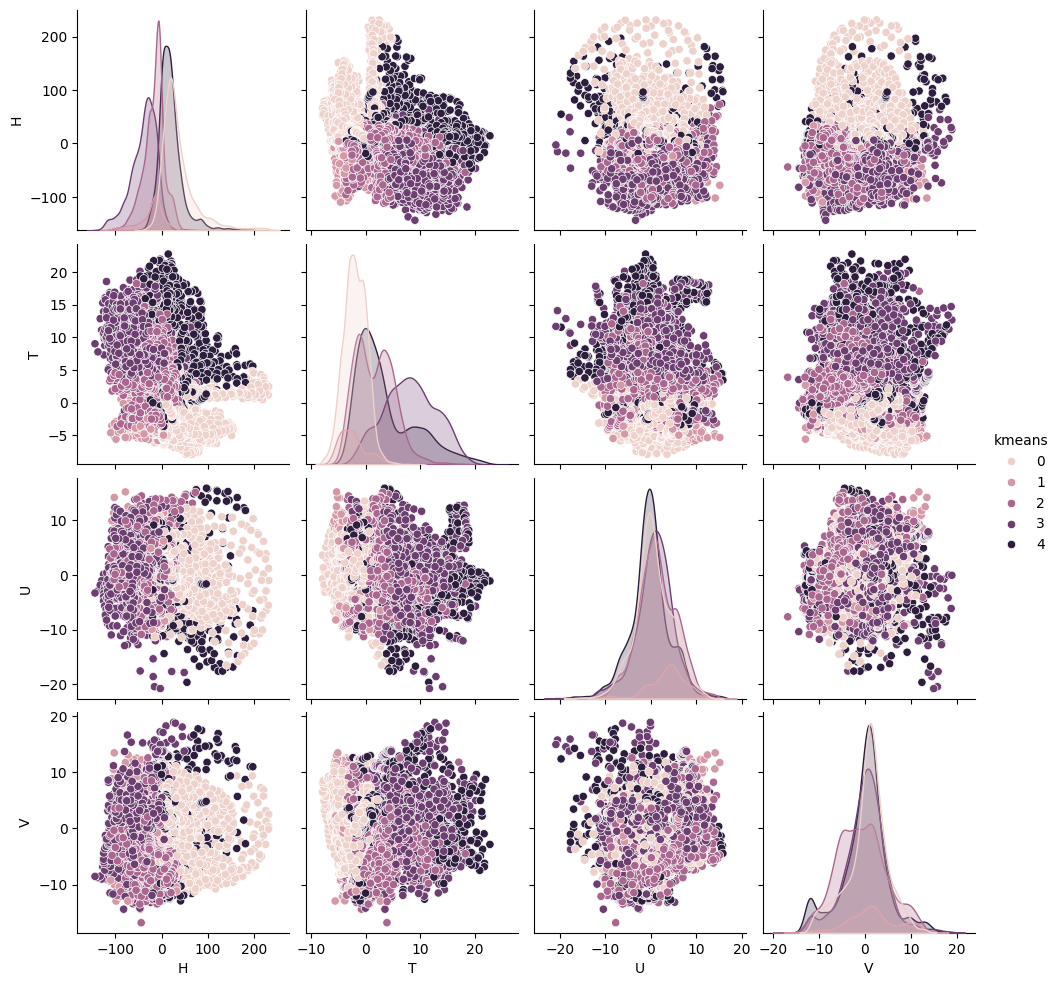

In [40]:
X_sns=X_ar.isel(time=0).to_dataframe()
sns.pairplot(X_sns, hue='kmeans')

In [41]:
print(X_df.shape)

(666120, 2)


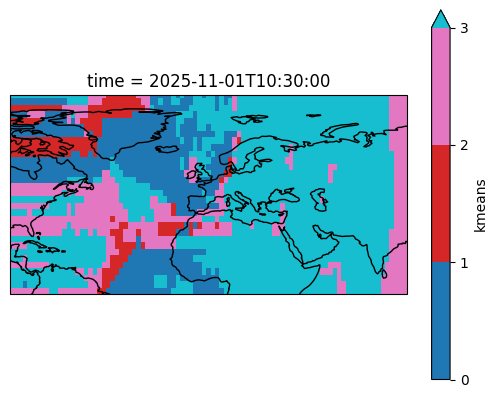

In [43]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
ax.coastlines()

X_ar['kmeans'].isel(time=0).plot(ax=ax, transform=ccrs.PlateCarree(), 
                                    cmap='tab10', levels=range(4))
plt.show()


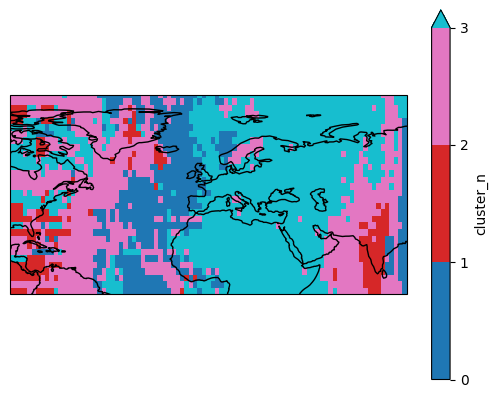

In [ ]:
#Вычисляем месячную моду
X_nov=X_ar.isel(time=slice(0,31))
X_nov=X_nov.rename({'kmeans' : 'cluster_n'})
mode_result = xr.apply_ufunc(
    stats.mode,
    X_nov['cluster_n'],
    input_core_dims=[['time']],  # ось, вдоль которой вычисляем моду
    output_core_dims=[[], []],    # два выхода: мода и частота
    vectorize=True,               # применяем к каждой пространственной точке
    dask='parallelized'           # если данные в Dask
)

fig = plt.figure()
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
ax.coastlines()
mode = mode_result[0]   # DataArray с модой (размерности x, y)
count = mode_result[1]
mode.plot(ax=ax, transform=ccrs.PlateCarree(), 
                                    cmap='tab10', levels=range(4))
#plt.show()
# plt.savefig('nov_mode.png')

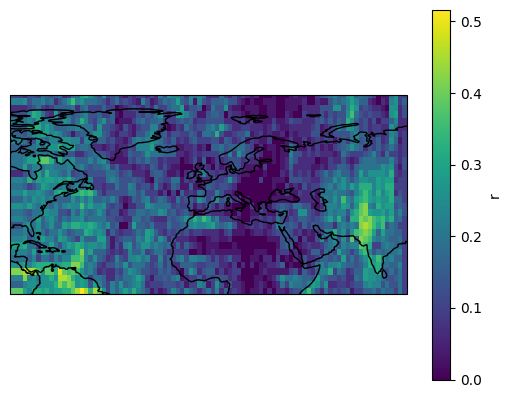

In [ ]:
X_nov=X_ar.isel(time=slice(0,31))
X_dec=X_ar.isel(time=slice(30,61))
X_nov_aligned = X_nov.assign_coords(time=range(31))
X_dec_aligned = X_dec.assign_coords(time=range(31))
X_nov_aligned=X_nov_aligned.rename({'kmeans' : 'r'})
X_dec_aligned=X_dec_aligned.rename({'kmeans' : 'r'})
# Сравниваем значения kmeans и усредняем по времени
r_da = (X_nov_aligned['r'] == X_dec_aligned['r']).mean(dim='time')

fig = plt.figure()
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
ax.coastlines()
r_da.plot(ax=ax, transform=ccrs.PlateCarree(), 
                                    cmap='viridis')
# plt.savefig('similarity_nov_dec.png')

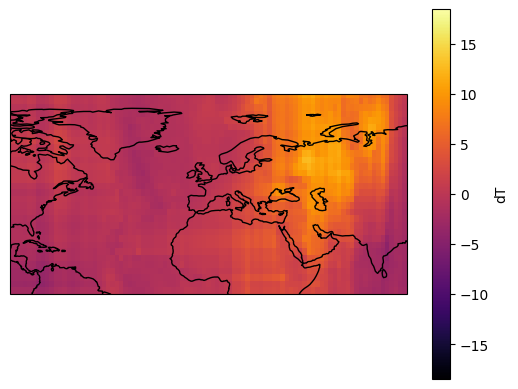

In [ ]:
X_nov=X_ar.isel(time=slice(0,31))
X_dec=X_ar.isel(time=slice(30,61))
X_nov_aligned = X_nov.assign_coords(time=range(31))
X_dec_aligned = X_dec.assign_coords(time=range(31))
X_nov_aligned=X_nov_aligned.rename({'H' : 'dH','T' : 'dT'})
X_dec_aligned=X_dec_aligned.rename({'H' : 'dH','T' : 'dT'})
r_da = (X_nov_aligned['dT'] - X_dec_aligned['dT']).mean(dim='time')

fig = plt.figure()
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
ax.coastlines()
r_da.plot(ax=ax, transform=ccrs.PlateCarree(), 
                                    cmap='inferno')
# plt.savefig('Error_T_nov_dec.png')

In [47]:
sum(sum(r_da)/len(r_da))/len(r_da)

<xarray.DataArray 'dT' ()> Size: 4B
array(0.87283486, dtype=float32)
Coordinates:
    lat      float64 8B 90.0

In [48]:
rows, cols = np.indices((len(r), len(r[0])))
x = cols.flatten()
y = rows.flatten()
values = np.array(r).flatten()


fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())


ax.scatter(x, y, c=values, cmap='viridis', transform=ccrs.PlateCarree())
ax.set_extent([-10, 60, 40, 70], crs=ccrs.PlateCarree())

plt.show()

NameError: name 'r' is not defined

In [ ]:
for i in range(len(X_ar.time)):
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
    ax.coastlines()

    X_ar['kmeans'].isel(time=i).plot(ax=ax, transform=ccrs.PlateCarree(), 
                                        cmap='tab10', levels=range(4))
    a=X_ar.time[i].dt.strftime('%Y%m%d').item()
    filename="Clusters_"+a+".png"
    plt.savefig(filename)
    ax.clear()
    plt.close()

In [ ]:
a=X_ar.time[i].dt.strftime('%Y%m%d').item()
a

'20251231'